<a href="https://colab.research.google.com/github/senaegilmezbas-ui/DSA210-PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 0: Upload Data
Data to be analyzed is uploaded.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Strava Activities.xlsx to Strava Activities.xlsx


#STEP 1: Setup and Data Loading

The analysis starts by importing the Python libraries used throughout the project. Pandas is used for data handling, matplotlib and seaborn for visualizations, and scipy for statistical analysis. After that, the Strava activity file is loaded into Python. Since the dataset covers runs recorded between 2017 and 2026, this step is mainly intended to make sure that the file is read correctly and that all observations are available before moving on to data cleaning and exploration.


In [9]:
#@title STEP 1: Import libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

df = pd.read_excel('Strava Activities.xlsx')

print(f"Dataset loaded successfully with {len(df)} total records.")

Dataset loaded successfully with 2858 total records.


#STEP 2: Data Cleaning

Before starting the analysis, the dataset was cleaned to remove records that were not suitable for the study. Since the original Strava export includes different activity types, only running activities were kept. Missing values in the main variables used for pace calculation were removed, and the activity date was converted into datetime format. A separate year variable was also created so that changes over time could be examined more clearly.

Next, pace was calculated in minutes per kilometer using moving time and distance. Because some activities may contain recording problems or unrealistic values, runs with extremely low or high pace values were excluded from the dataset. Finally, each run was assigned to a pre-COVID, COVID, or post-COVID period in order to support the comparison used in the first hypothesis.

In [10]:
#@title STEP 2

# Keep only running activities
df_runs = df[df['Activity Type'] == 'Run'].copy()

# Remove missing values in variables needed for pace calculation
df_runs = df_runs.dropna(subset=['Moving Time', 'Distance'])

# Convert dates and extract year information
df_runs['Activity Date'] = pd.to_datetime(df_runs['Activity Date'])
df_runs['Year'] = df_runs['Activity Date'].dt.year

# Calculate pace in minutes per kilometer
df_runs['Pace'] = (df_runs['Moving Time'] / 60) / df_runs['Distance']

# Remove unrealistic pace values
df_runs = df_runs[(df_runs['Pace'] > 3) & (df_runs['Pace'] < 12)]

# Create time periods for COVID-related comparison
def get_covid_period(year):
    if year <= 2019:
        return 'Pre-COVID'
    elif year <= 2021:
        return 'COVID'
    else:
        return 'Post-COVID'

df_runs['COVID_Period'] = df_runs['Year'].apply(get_covid_period)

print(f"After cleaning, {len(df_runs)} running activities remain for analysis.")

After cleaning, 2162 running activities remain for analysis.


#STEP 3: Hypothesis 1 – COVID-19 and Running Pace

Hypothesis

H0: There is no difference in average running pace between the COVID-19 period (2020–2021) and the pre/post-pandemic periods.  
H1: There is a difference in average running pace between the COVID-19 period (2020–2021) and the pre/post-pandemic periods.  

Expected Direction: It is expected that running pace may have become slower during the COVID-19 period due to changes in training conditions.

.....


This part of the analysis focuses on the first hypothesis, which examines whether running pace changed during the COVID-19 period. In this analysis, pace is measured in minutes per kilometer, meaning that higher values indicate slower running performance.

To explore this, a box plot is first used to compare the distribution of pace values across the pre-COVID, COVID, and post-COVID periods. The box plot makes it easier to observe differences in median pace as well as the overall spread and variability in each period.

After this visual comparison, an independent samples t-test is performed to directly compare the pre-COVID and COVID groups. The goal is to determine whether the difference in average pace between these two periods is statistically significant.

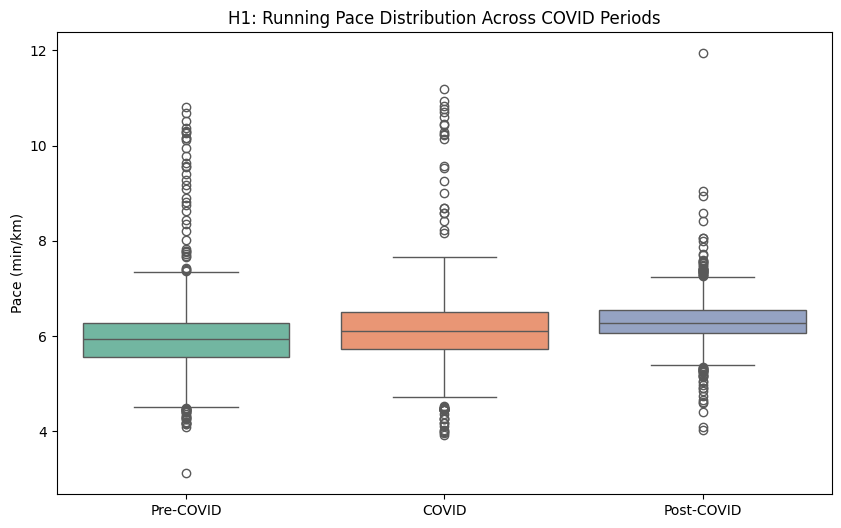

H1 Results: T-statistic = -3.4134, P-value = 0.0007
Conclusion: The difference in average pace between the pre-COVID and COVID periods is statistically significant.


In [7]:
#@title STEP 3

# Box plot of pace across COVID periods
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_runs,
    x='COVID_Period',
    y='Pace',
    order=['Pre-COVID', 'COVID', 'Post-COVID'],
    hue='COVID_Period',
    dodge=False,
    palette='Set2',
    legend=False
)
plt.title('H1: Running Pace Distribution Across COVID Periods')
plt.ylabel('Pace (min/km)')
plt.xlabel('')
plt.show()

# Independent samples t-test: Pre-COVID vs COVID
group_pre = df_runs[df_runs['COVID_Period'] == 'Pre-COVID']['Pace']
group_covid = df_runs[df_runs['COVID_Period'] == 'COVID']['Pace']

t_stat, p_val = stats.ttest_ind(group_pre, group_covid, equal_var=False, nan_policy='omit')
print(f"H1 Results: T-statistic = {t_stat:.4f}, P-value = {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The difference in average pace between the pre-COVID and COVID periods is statistically significant.")
else:
    print("Conclusion: No statistically significant difference was found between the pre-COVID and COVID periods.")

Interpretation of Results

The results suggest that average pace increased slightly during the COVID period compared to the pre-COVID period. Since pace is measured in minutes per kilometer, this indicates a small decline in running performance. Although the difference is relatively modest, the t-test results show that it is statistically significant.

The observed changes in pace may also reflect differences in training composition (e.g., more easy or long runs) rather than a pure decline in performance, which should be considered when interpreting the results.

#STEP 4: Hypothesis 2 – Elevation and Running Pace

Hypothesis

H0: There is no difference in running pace between low-elevation and high-elevation runs.  
H1: Running pace differs between low-elevation and high-elevation runs.

Expected Direction: Runs with higher elevation are expected to result in slower pace values due to increased physical demand.

.....

This part of the analysis examines the second hypothesis, which focuses on the relationship between elevation gain and running pace. Since pace is measured in minutes per kilometer, higher values indicate slower performance.

To explore this relationship, a scatter plot is used to visualize how pace changes with increasing elevation gain. In addition, the activities are divided into two groups based on the median elevation gain (low and high elevation) to allow for a more direct comparison.

An independent samples t-test is then used to compare the average pace between these two groups and determine whether any observed difference is statistically significant.


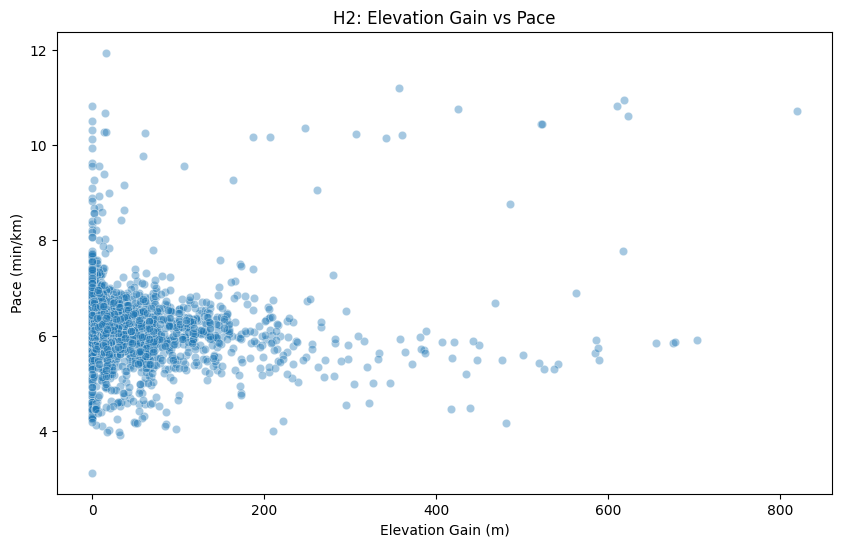

H2 Results: T-statistic = 4.4886, P-value = 0.0000
Conclusion: The difference between low and high elevation runs is statistically significant.


In [11]:
#@title STEP 4

# Create elevation groups based on median
median_elev = df_runs['Elevation Gain'].median()
df_runs['Elevation_Group'] = df_runs['Elevation Gain'].apply(
    lambda x: 'High' if x > median_elev else 'Low'
)

# Scatter plot: Elevation vs Pace
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_runs,
    x='Elevation Gain',
    y='Pace',
    alpha=0.4
)
plt.title('H2: Elevation Gain vs Pace')
plt.xlabel('Elevation Gain (m)')
plt.ylabel('Pace (min/km)')
plt.show()

# T-test: Low vs High elevation
low_elev = df_runs[df_runs['Elevation_Group'] == 'Low']['Pace']
high_elev = df_runs[df_runs['Elevation_Group'] == 'High']['Pace']

t_stat_e, p_val_e = stats.ttest_ind(low_elev, high_elev, equal_var=False, nan_policy='omit')
print(f"H2 Results: T-statistic = {t_stat_e:.4f}, P-value = {p_val_e:.4f}")

if p_val_e < 0.05:
    print("Conclusion: The difference between low and high elevation runs is statistically significant.")
else:
    print("Conclusion: No statistically significant difference was found between low and high elevation runs.")

Interpretation of Results

The results indicate that runs with higher elevation tend to result in slightly slower paces. Although the relationship is not very strong, the t-test results show that the difference between low and high elevation runs is statistically significant.

The observed relationship between elevation and pace may partly explain the differences seen in the previous analysis, as runs with higher elevation tend to result in slightly slower paces.

#STEP 5: Hypothesis 3 – Aging and Running Performance

Hypothesis

H0: There is no relationship between year and running pace.  
H1: There is a relationship between year and running pace.

Expected Direction: It is expected that running performance may decline slightly over time due to aging effects.

.....

This part of the analysis examines the third hypothesis, which focuses on how running performance has changed over time. Since the dataset spans multiple years, it allows for a longitudinal analysis of performance trends.

To explore this relationship, a scatter plot with a regression line is used to visualize how running pace changes over time. This approach allows us to observe the overall trend while also preserving the variability across individual runs.

Additionally, a Pearson correlation test is conducted to measure the strength and direction of the relationship between year and pace, and to determine whether the observed trend is statistically significant.

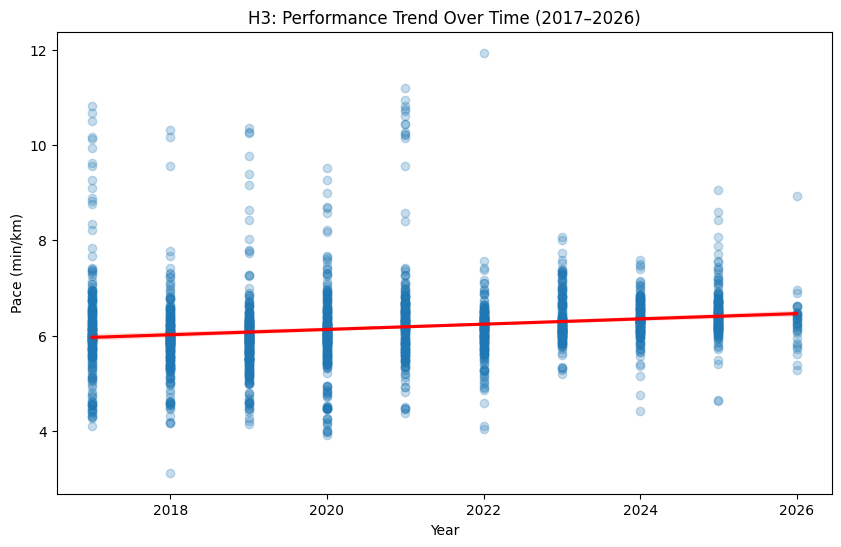

H3 Results: Pearson Correlation = 0.1692, P-value = 0.0000
Conclusion: There is a statistically significant relationship between year and pace.


In [15]:
#@title STEP 5

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_runs,
    x='Year',
    y='Pace',
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'red'}
)

plt.title('H3: Performance Trend Over Time (2017–2026)')
plt.xlabel('Year')
plt.ylabel('Pace (min/km)')
plt.show()

# Pearson correlation
corr, p_val_corr = stats.pearsonr(df_runs['Year'], df_runs['Pace'])
print(f"H3 Results: Pearson Correlation = {corr:.4f}, P-value = {p_val_corr:.4f}")

if p_val_corr < 0.05:
    print("Conclusion: There is a statistically significant relationship between year and pace.")
else:
    print("Conclusion: No statistically significant relationship was found between year and pace.")

Interpretation of Results

The results indicate a weak positive relationship between year and running pace, suggesting that pace has slightly increased over time. Since pace is measured in minutes per kilometer, this implies a small decline in running performance.

Although the correlation is relatively weak, the Pearson correlation test shows that the relationship is statistically significant. This suggests that the observed trend is unlikely to be due to random variation.

However, this trend may also reflect changes in training patterns, intensity, or running conditions over the years, rather than a pure effect of aging alone.

#STEP 6: Hypothesis 4 - Cardiovascular Efficiency

H0: There is no relationship between weekly training frequency and average heart rate.  
H1: There is a relationship between weekly training frequency and average heart rate.

Expected Direction: Higher training frequency is expected to be associated with lower average heart rate, indicating improved cardiovascular efficiency.

.....

This part of the analysis examines the relationship between training frequency and cardiovascular efficiency.

To approximate training frequency, the number of runs per week is calculated. This is then compared with the athlete’s average heart rate to explore whether increased training frequency is associated with improved physiological adaptation.

A correlation matrix is used to examine the relationships between weekly training frequency, heart rate, pace, and distance, providing a broader view of how these variables interact.

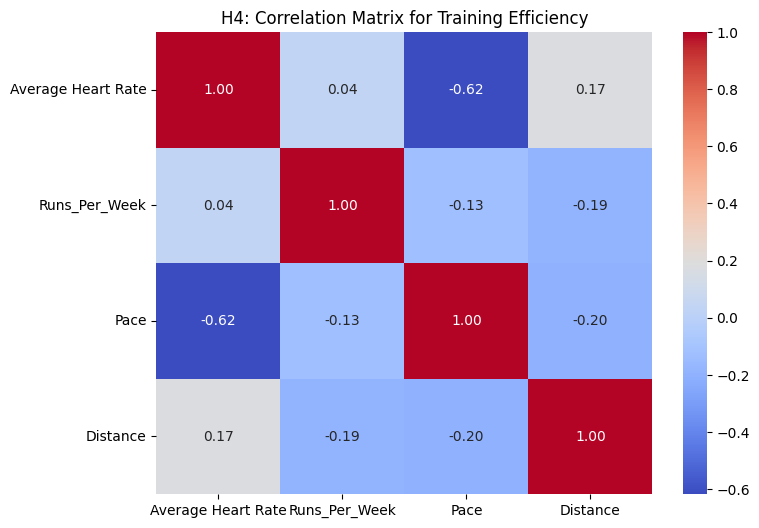

In [12]:
#@title STEP 6

# Create weekly identifier
df_runs['Week'] = df_runs['Activity Date'].dt.isocalendar().week
df_runs['Year_Week'] = df_runs['Year'].astype(str) + "-" + df_runs['Week'].astype(str)

# Calculate runs per week (training frequency)
weekly_freq = df_runs.groupby('Year_Week').size().reset_index(name='Runs_Per_Week')

# Merge back to main dataset
df_hr = df_runs.merge(weekly_freq, on='Year_Week')

# Select relevant variables and drop missing values
hr_analysis = df_hr[['Average Heart Rate', 'Runs_Per_Week', 'Pace', 'Distance']].dropna()

# Compute correlation matrix
corr_matrix = hr_analysis.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('H4: Correlation Matrix for Training Efficiency')
plt.show()

Conclusion

This study analyzed the impact of multiple factors on running performance over a 9-year period. The results indicate that performance is influenced by a combination of temporal, environmental, and physiological variables.

A statistically significant difference in pace was observed during the COVID-19 period, suggesting that external conditions may have affected training outcomes. Elevation was also found to have a significant effect, with higher elevation runs associated with slightly slower paces.

In addition, a weak but significant trend over time suggests that performance may have changed gradually, although this cannot be attributed solely to aging. Finally, no meaningful relationship was found between training frequency and heart rate, indicating that frequency alone is not sufficient to explain cardiovascular efficiency.

Overall, the findings suggest that running performance is multifactorial and should be interpreted within the broader context of training conditions, environmental factors, and workout composition.

Limitations

This analysis has several limitations. First, the dataset includes different types of runs (e.g., long runs, easy runs, and high-intensity sessions), which may affect pace independently of the variables analyzed.

Second, elevation gain was used as a proxy for terrain difficulty, which may not fully capture environmental differences such as surface type or weather conditions.

Third, training frequency was measured as the number of runs per week, which does not account for training intensity or recovery.

Finally, the dataset represents a single athlete, which limits the generalizability of the findings.